# Phase 1 — Surface Gallery (Real Data)

Per-date IV-surface visuals on the **real SPY benchmark**
(`spy_phase1_random40_noiselow`), reconstructed with the per-date RBF
interpolation baseline:

1. Reference (clean) surface
2. Sparse observed input → reconstructed surface (triptych, shared IV scale)
3. Spatial absolute-error map — *where* the model fails
4. Joint maturity × moneyness error heatmap

This notebook **requires the benchmark parquet** and is therefore executed on
RunPod (the data lives only there). It uses the tested
`neural_iv_surface_inference.viz` module and the interpolation baseline (no
checkpoint, deterministic).

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from neural_iv_surface_inference.viz import (
    apply_house_style,
    plot_surface_scatter,
    plot_reconstruction_triptych,
    plot_spatial_error,
    plot_joint_error_heatmap,
)
from neural_iv_surface_inference.models.interpolation import run_interpolation_baseline
from neural_iv_surface_inference.training.eval import (
    evaluate_predictions_2d,
    evaluate_predictions_2d_counts,
)

apply_house_style()

# Parameters (override via env var if desired).
BENCHMARK = Path(os.environ.get(
    "IV_BENCHMARK",
    ROOT / "data_processed/spy/benchmarks/spy_phase1_random40_noiselow.parquet",
))
METHOD = "rbf"
HEATMAP_MAX_DATES = 60
print("benchmark:", BENCHMARK)
print("exists:", BENCHMARK.exists())

benchmark: /workspace/Neural-IV-Surface-inference/data_processed/spy/benchmarks/spy_phase1_random40_noiselow.parquet
exists: True


In [2]:
cols = ["date", "tau", "log_moneyness", "iv_clean",
        "implied_volatility", "observed", "split"]
df = pd.read_parquet(BENCHMARK, columns=cols)
test_df = df[df["split"] == "test"]
test_dates = sorted(test_df["date"].unique())
print(f"test rows: {len(test_df):,}  test dates: {len(test_dates):,}")

test rows: 5,310,219  test dates: 678


## 1. Reference surface (sample date)

The clean target surface in (log-moneyness, tau) space for one test date.

2023-04-03: 6,351 points, 2,593 observed


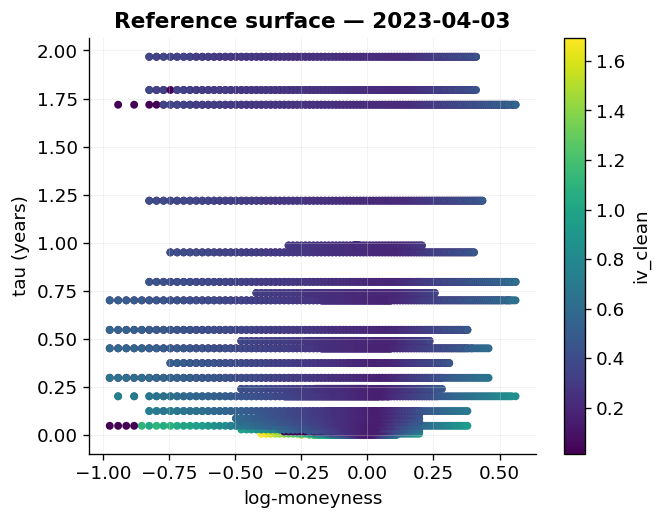

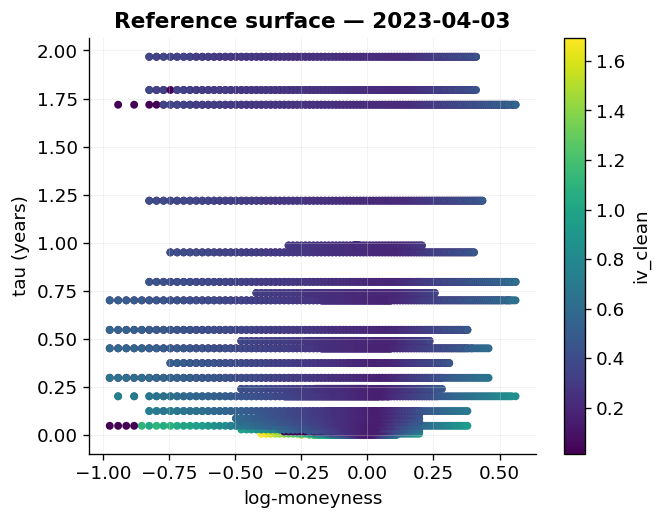

In [3]:
sample_date = test_dates[0]
sample = test_df[test_df["date"] == sample_date].copy()
sample["iv_pred"] = run_interpolation_baseline(sample, method=METHOD, verbose=False)
label = str(pd.Timestamp(sample_date).date())
print(f"{label}: {len(sample):,} points, {int(sample['observed'].sum()):,} observed")
plot_surface_scatter(sample, value_col="iv_clean", title=f"Reference surface — {label}")

## 2. Sparse observed → reconstructed (triptych)

Reference (clean) | sparse observed input | RBF reconstruction, on a shared IV
colour scale. This is the clearest single picture of the reconstruction task.

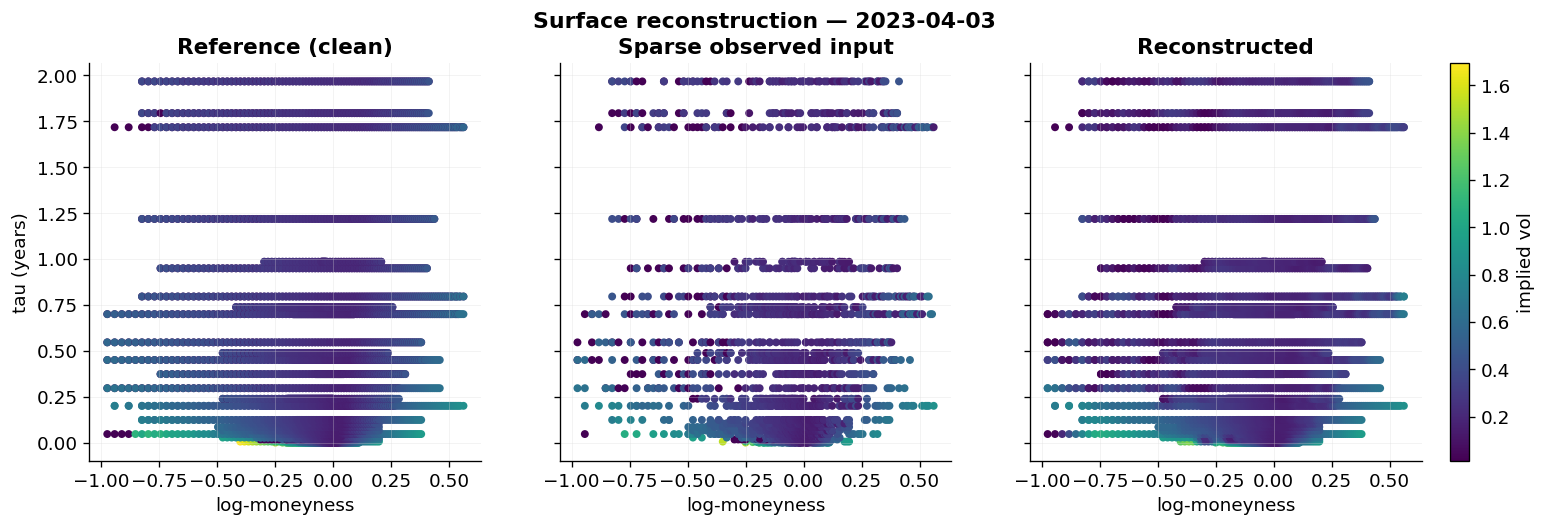

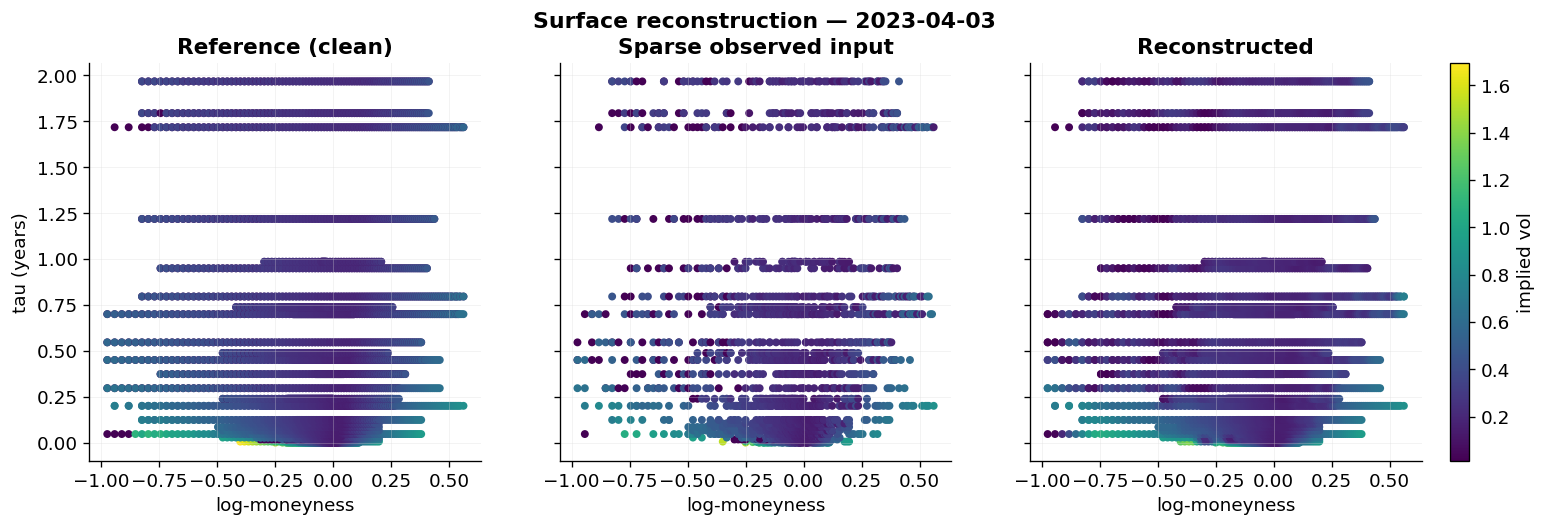

In [4]:
plot_reconstruction_triptych(sample, date_label=label)

## 3. Spatial absolute-error map

Where the reconstruction is least accurate — typically short maturity and the
deep wings.

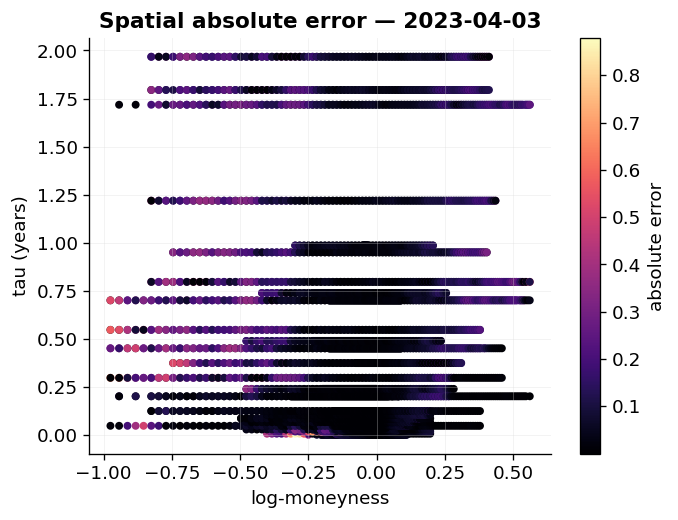

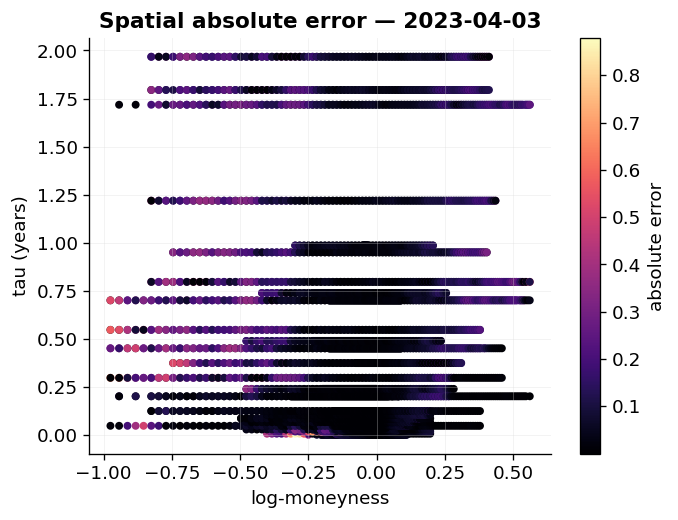

In [5]:
plot_spatial_error(sample, title=f"Spatial absolute error — {label}")

## 4. Joint maturity × moneyness error heatmap

Joint MAE grid over a capped set of test dates (per-date RBF over all 678 test
dates is slow). Reveals the joint structure the marginal breakdowns in notebook
02 cannot.

heatmap over 60 dates, 389,383 points


,deep_itm,itm,atm,otm,deep_otm
short,0.1399,0.0895,0.0228,0.0483,0.0258
medium,0.1489,0.0244,0.0111,0.0573,0.0718
long,0.1412,0.0277,0.0224,0.0479,0.1316


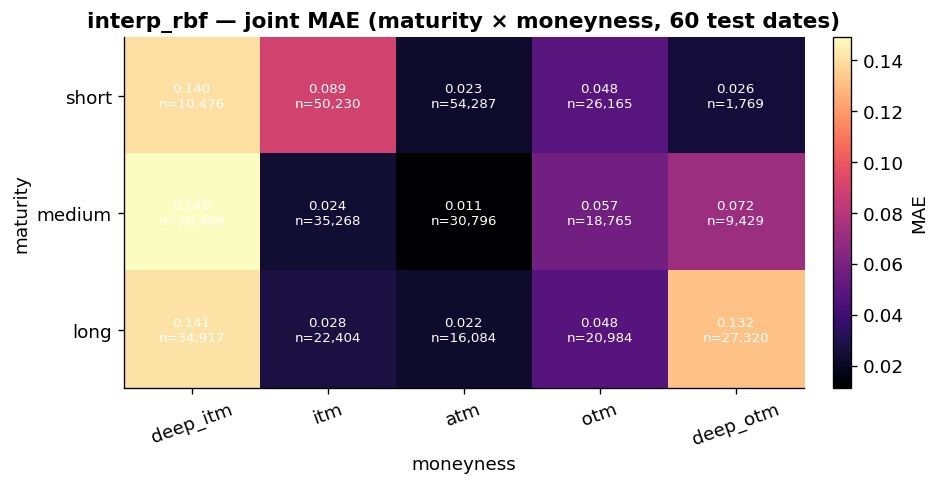

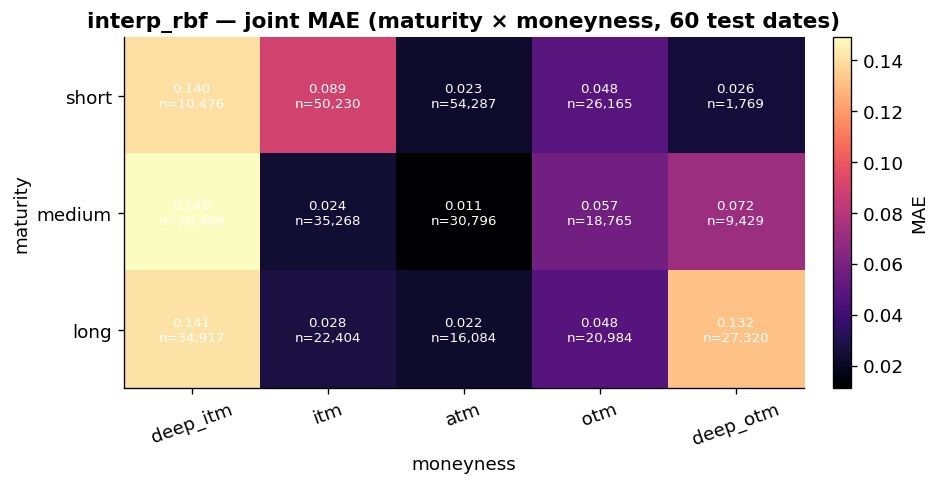

In [6]:
keep = test_dates[:HEATMAP_MAX_DATES]
sub = test_df[test_df["date"].isin(keep)].copy()
sub["iv_pred"] = run_interpolation_baseline(sub, method=METHOD, verbose=False)
grid = evaluate_predictions_2d(sub, metric="mae")
counts = evaluate_predictions_2d_counts(sub)
print(f"heatmap over {len(keep)} dates, {len(sub):,} points")
display(grid.round(4))
plot_joint_error_heatmap(grid, counts,
    title=f"interp_{METHOD} — joint MAE (maturity × moneyness, {len(keep)} test dates)")

## 5. Interpretation

- The triptych shows RBF interpolation recovers the broad smile/term structure
  from sparse observed quotes, but smooths over local curvature.
- The spatial error map and joint heatmap agree with the aggregate breakdowns:
  error concentrates at **short maturity** and the **deep wings**
  (deep-ITM / deep-OTM), the economically hardest regions.
- These are exactly the regions a Phase 2 structure-aware / mask-conditioned
  model should target.